# Module End Assignment – Python For Data Analysis
## Social Media Engagement Analytics Using Python

**Dataset:** `social_media_engagement_5000.csv`

### TASK 1 - DATA IMPORT & SETUP

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [89]:
df = pd.read_csv("social_media_engagement_5000.csv")

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)
df.head()


Dataset loaded successfully.
Rows and columns: (5000, 19)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [90]:
print(df.dtypes)

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object


In [91]:
df["posted_at"] = pd.to_datetime(df["posted_at"],format="%d-%m-%Y",errors="coerce")
print(df["posted_at"].dtype)

datetime64[us]


In [92]:
likes_array = df["likes"].dropna().to_numpy()

print("First 10 likes:", likes_array[:10])
print("Shape:", likes_array.shape)
print("Array Size:", likes_array.size)
print("Maximum likes:", np.max(likes_array))
print("Minimum likes:", np.min(likes_array))
print("Average likes:", np.mean(likes_array))

First 10 likes: [ 7011. 11750.  4862.  5350. 12682. 12535. 11703.  9611. 14106.   355.]
Shape: (4850,)
Array Size: 4850
Maximum likes: 19998.0
Minimum likes: 10.0
Average likes: 10107.043711340206


### TASK 2 — DATA CLEANING

#### Cleaning Missing Data

In [93]:
print("Missing values using isnull():")
print(df.isnull().sum())


print("\nMissing values using isna():")
print(df.isna().sum())


Missing values using isnull():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Missing values using isna():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [94]:
missing_columns = df.isnull().sum()

print("Columns with missing values:")
print(missing_columns[missing_columns > 0])

Columns with missing values:
age          150
gender       150
likes        150
comments     150
shares       150
sentiment    150
dtype: int64


In [95]:

df_dropna = df.dropna()

print("Original number of rows:", len(df))
print("Rows after dropna():", len(df_dropna))

Original number of rows: 5000
Rows after dropna(): 4162


In [96]:
numeric_columns = ["age", "likes", "comments", "shares"]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Numerical missing values filled using median.")

Numerical missing values filled using median.


In [97]:
categorical_columns = ["gender", "sentiment"]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Categorical missing values filled using mode.")

Categorical missing values filled using mode.


In [98]:
df = df.ffill().bfill()
print("Remaining missing values handled using forward-fill and backward-fill.")

Remaining missing values handled using forward-fill and backward-fill.


In [99]:
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


#### Duplicate Handling

In [100]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Number of rows after removing duplicates:", len(df))

Number of duplicate rows: 0
Number of duplicate rows after removal: 0
Number of rows after removing duplicates: 5000


#### Data Formatting

In [101]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df["likes"] = pd.to_numeric(df["likes"], errors="coerce")
df["comments"] = pd.to_numeric(df["comments"], errors="coerce")
df["shares"] = pd.to_numeric(df["shares"], errors="coerce")

df["posted_at"] = pd.to_datetime(df["posted_at"],format="%d-%m-%Y",errors="coerce")

df["is_verified"] = df["is_verified"].astype(bool)

print("Data types after formatting:")
print(df.dtypes)


Data types after formatting:
user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object


In [102]:
df["gender"] = df["gender"].astype(str).str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female",
    "o": "Other",
    "other": "Other"
})

print("\nStandardized gender categories:")
print(df["gender"].value_counts())



Standardized gender categories:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64


In [103]:
df.loc[df["likes"] < 0, "likes"] = np.nan
df.loc[df["comments"] < 0, "comments"] = np.nan
df.loc[df["shares"] < 0, "shares"] = np.nan


In [104]:
df["likes"] = df["likes"].fillna(df["likes"].median())
df["comments"] = df["comments"].fillna(df["comments"].median())
df["shares"] = df["shares"].fillna(df["shares"].median())

print("\nUnrealistic values corrected.")



Unrealistic values corrected.


In [105]:
print("\nNegative values after correction:")
print("Likes:", (df["likes"] < 0).sum())
print("Comments:", (df["comments"] < 0).sum())
print("Shares:", (df["shares"] < 0).sum())


Negative values after correction:
Likes: 0
Comments: 0
Shares: 0


#### Feature Cleaning

In [106]:
df["hashtag_count"] = df["hashtags"].fillna("").str.count("#")

print("Hashtag count extracted successfully.")
print(df[["hashtags", "hashtag_count"]].head())


Hashtag count extracted successfully.
                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [107]:
df["sentiment"] = (
    df["sentiment"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

df["sentiment"] = df["sentiment"].replace({
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
})

print("\nCleaned sentiment labels:")
print(df["sentiment"].value_counts())

# Final check
print("\nFeature Cleaning completed successfully.")
print(df[["hashtags", "hashtag_count", "sentiment"]].head())


Cleaned sentiment labels:
sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64

Feature Cleaning completed successfully.
                hashtags  hashtag_count sentiment
0  #foodie #travel #love              3  Negative
1               #fitness              1  Negative
2                #foodie              1  Positive
3    #music #foodie #fun              3  Negative
4                #travel              1  Negative


### Task 3 — Data Exploration using Pandas

In [108]:
print("HEAD")
display(df.head())

print("\nTAIL")
display(df.tail())

print("\nSHAPE")
print(df.shape)

print("\nCOLUMNS")
print(df.columns.tolist())


HEAD


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1



TAIL


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3



SHAPE
(5000, 20)

COLUMNS
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [109]:
print("\nDATASET INFORMATION :")
df.info()

print("\nDATA TYPES :")
print(df.dtypes)



DATASET INFORMATION :
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified 

In [110]:
print("\nSUMMARY STATISTICS :")
print(df.describe())


SUMMARY STATISTICS :
            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.997400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5702.293017   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%  

In [111]:
categorical_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in categorical_columns:
    print("\n---", col, "---")

    print("Value Counts:")
    print(df[col].value_counts())

    print("Unique Values:")
    print(df[col].unique())

    print("Number of Unique Values:")
    print(df[col].nunique())


--- gender ---
Value Counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
Unique Values:
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Number of Unique Values:
3

--- country ---
Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
Unique Values:
<StringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: str
Number of Unique Values:
10

--- post_type ---
Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
Unique Values:
<StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str
Number of Unique Values:
4

--- post_category ---
Value Counts:
post_category
fitness      675
tech         665
music        635

In [112]:
print("\nCORRELATION MATRIX :")

numeric_columns = ["age","likes","comments","shares","watch_time_sec","impression_count","follower_count","engagement_rate","hashtag_count"]

correlation_matrix = df[numeric_columns].corr()
display(correlation_matrix.round(3))


CORRELATION MATRIX :


,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.000,-0.036,-0.007,0.014,0.006,0.013,-0.025,0.008,0.007
likes,-0.036,1.000,-0.018,0.005,0.009,0.008,-0.023,0.094,-0.002
comments,-0.007,-0.018,1.000,0.006,-0.016,-0.009,-0.012,0.000,-0.015
shares,0.014,0.005,0.006,1.000,0.015,-0.005,-0.011,0.022,0.013
watch_time_sec,0.006,0.009,-0.016,0.015,1.000,-0.004,0.003,-0.001,-0.023
impression_count,0.013,0.008,-0.009,-0.005,-0.004,1.000,-0.016,-0.232,-0.003
follower_count,-0.025,-0.023,-0.012,-0.011,0.003,-0.016,1.000,0.002,0.009
engagement_rate,0.008,0.094,0.000,0.022,-0.001,-0.232,0.002,1.000,0.005
hashtag_count,0.007,-0.002,-0.015,0.013,-0.023,-0.003,0.009,0.005,1.000


In [113]:
# Average likes by post type
avg_likes_by_post_type = df.groupby("post_type")["likes"].mean()

print("Average Likes by Post Type:")
print(avg_likes_by_post_type)


# Average impressions by country
avg_impressions_by_country = df.groupby("country")["impression_count"].mean()

print("\nAverage Impressions by Country:")
print(avg_impressions_by_country)


# Average comments by sentiment
avg_comments_by_sentiment = df.groupby("sentiment")["comments"].mean()

print("\nAverage Comments by Sentiment:")
print(avg_comments_by_sentiment)

Average Likes by Post Type:
post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64

Average Impressions by Country:
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64

Average Comments by Sentiment:
sentiment
Negative    1516.094792
Neutral     1528.404060
Positive    1480.650617
Name: comments, dtype: float64


### Task 4 — Data Wrangling

In [114]:
df["engagement_score"] = ( df["likes"] + df["comments"] + df["shares"] )

print("Engagement score")
print(df[["likes", "comments", "shares", "engagement_score"]].head())

df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])

print("\nLog-transformed metrics")
print(df[["log_likes", "log_comments", "log_shares"]].head())

# hashtag_count was already created in Task 2 — Feature Cleaning.
print("\nHashtag count")
print(df[["hashtags", "hashtag_count"]].head())


Engagement score
     likes  comments  shares  engagement_score
0   7011.0     354.0  1157.0            8522.0
1  11750.0    2606.0  1807.0           16163.0
2   4862.0     344.0   955.0            6161.0
3   5350.0    1083.0  1049.0            7482.0
4  12682.0    2735.0  1300.0           16717.0

Log-transformed metrics
   log_likes  log_comments  log_shares
0   8.855378      5.872118    7.054450
1   9.371694      7.865955    7.499977
2   8.489411      5.843544    6.862758
3   8.585039      6.988413    6.956545
4   9.448018      7.914252    7.170888

Hashtag count
                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [115]:
post_type_summary = df.groupby("post_type").agg(
    average_likes=("likes", "mean"),
    average_comments=("comments", "mean"),
    average_shares=("shares", "mean"),
    average_engagement_score=("engagement_score", "mean"),
    average_engagement_rate=("engagement_rate", "mean")
).round(2)

print("===== GROUPBY BY POST TYPE =====")
print(post_type_summary)

country_summary = df.groupby("country").agg(
    average_likes=("likes", "mean"),
    average_impressions=("impression_count", "mean"),
    average_engagement_score=("engagement_score", "mean"),
    average_engagement_rate=("engagement_rate", "mean")
).round(2)

print("\n===== GROUPBY BY COUNTRY =====")
print(country_summary)

sentiment_summary = df.groupby("sentiment").agg(
    average_likes=("likes", "mean"),
    average_comments=("comments", "mean"),
    average_shares=("shares", "mean"),
    average_engagement_score=("engagement_score", "mean"),
    average_engagement_rate=("engagement_rate", "mean")
).round(2)

print("\n===== GROUPBY BY SENTIMENT =====")
print(sentiment_summary)

===== GROUPBY BY POST TYPE =====


           average_likes  average_comments  average_shares  \
post_type                                                    
image           10104.87           1525.24         1019.29   
reel            10037.80           1504.19          982.04   
text            10100.15           1499.11         1013.99   
video           10188.60           1479.16          996.83   

           average_engagement_score  average_engagement_rate  
post_type                                                     
image                      12649.39                     0.90  
reel                       12524.03                     0.78  
text                       12613.24                     1.06  
video                      12664.59                     1.12  

===== GROUPBY BY COUNTRY =====
           average_likes  average_impressions  average_engagement_score  \
country                                                                   
Australia       10294.12             48346.38                  128

### Task 5 — Statistical Analysis


In [116]:
statistical_columns = ["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]

statistics_table = pd.DataFrame({
    "Mean": df[statistical_columns].mean(),
    
    "Median": df[statistical_columns].median(),
    
    "Mode": df[statistical_columns].mode().iloc[0],
    
    "Standard Deviation": df[statistical_columns].std(),
    
    "Variance": df[statistical_columns].var(),
    
    "25th Percentile": df[statistical_columns].quantile(0.25),
    "50th Percentile": df[statistical_columns].quantile(0.50), 
    "75th Percentile": df[statistical_columns].quantile(0.75),
    
    "Skewness": df[statistical_columns].skew(),
    "Kurtosis": df[statistical_columns].kurtosis()
})
display(statistics_table.round(2))


,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,Skewness,Kurtosis
likes,10107.00,10105.50,10105.50,5702.29,3.251615e+07,5235.00,10105.50,14959.00,-0.01,-1.15
comments,1502.04,1497.00,1497.00,856.39,7.334095e+05,792.00,1497.00,2235.25,0.00,-1.14
shares,1002.91,1012.00,1012.00,570.86,3.258757e+05,511.00,1012.00,1483.00,-0.01,-1.15
watch_time_sec,4014.50,4034.50,916.00,2308.10,5.327309e+06,2017.75,4034.50,6020.25,-0.02,-1.20
engagement_rate,0.96,0.25,0.01,5.32,2.828000e+01,0.15,0.25,0.50,18.78,482.99
follower_count,393698.22,388982.00,497502.00,230927.88,5.332769e+10,194480.00,388982.00,589744.25,0.04,-1.19


###  Task 6 — Data Visualization 

### Matplotlib

#### 1. Scatter Plot — Likes vs Impressions

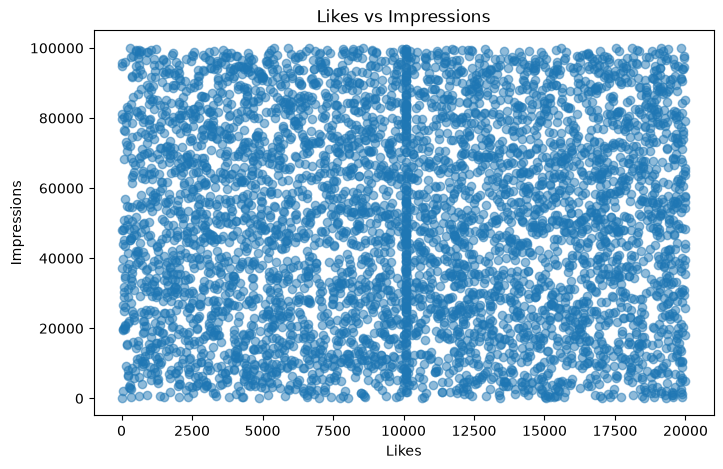

In [117]:
plt.figure(figsize=(8, 5))
plt.scatter(df["likes"],df["impression_count"],alpha=0.5)

plt.title("Likes vs Impressions")
plt.xlabel("Likes")
plt.ylabel("Impressions")

plt.show()

#### 2. Line Chart — Daily Engagement Trend

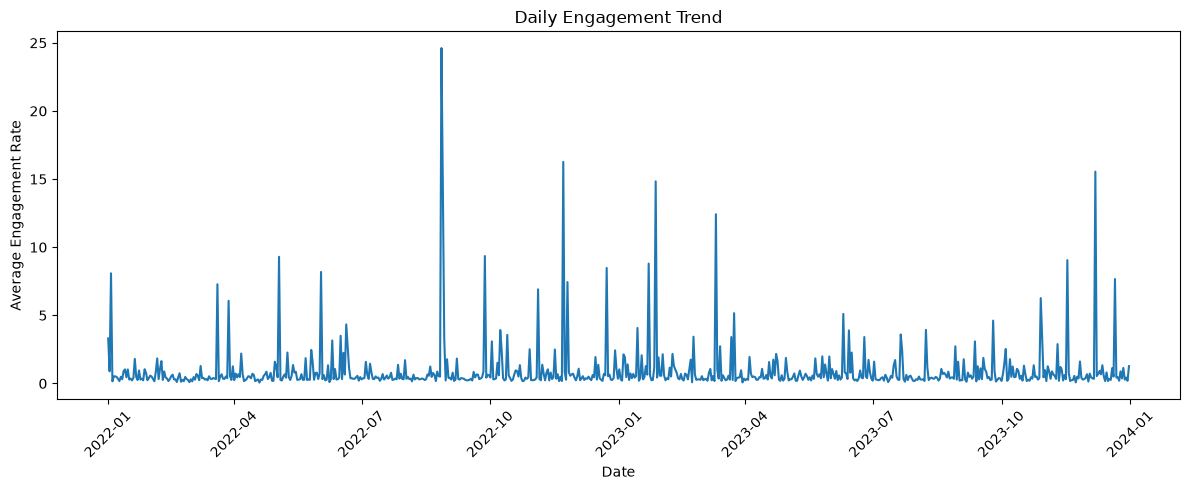

In [118]:
daily_engagement = (
    df.groupby("posted_at")["engagement_rate"]
    .mean()
    .reset_index()
    .sort_values("posted_at")
)

plt.figure(figsize=(12, 5))
plt.plot(daily_engagement["posted_at"],daily_engagement["engagement_rate"])
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3. Bar Chart — Posts by Category

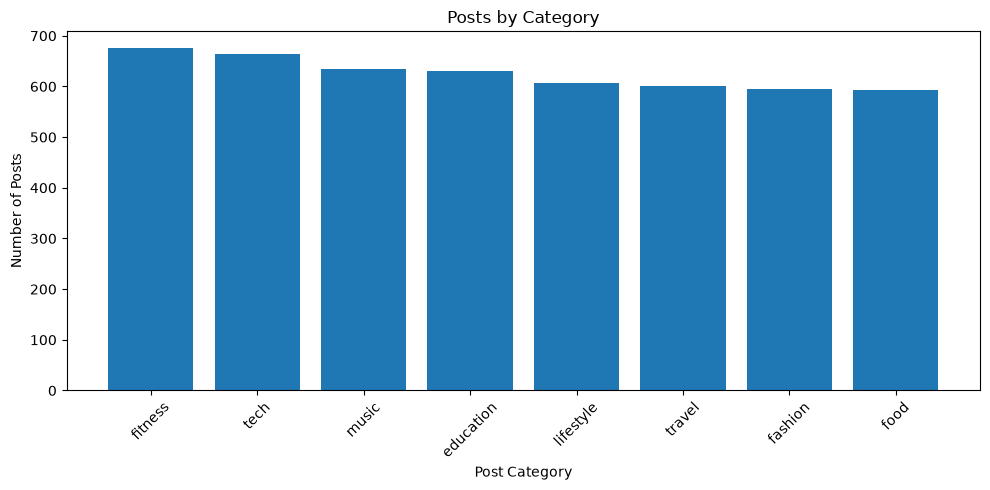

In [119]:
posts_by_category = df["post_category"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(posts_by_category.index,posts_by_category.values)

plt.title("Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4. Pie Chart — Gender Distribution

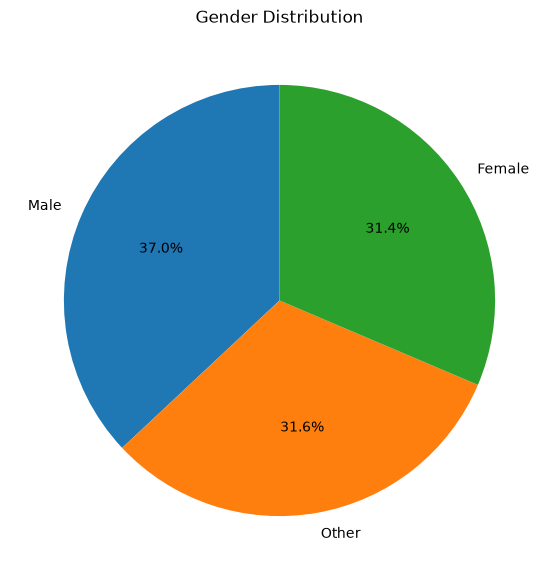

In [120]:
gender_counts = df["gender"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(gender_counts.values,labels=gender_counts.index,autopct="%1.1f%%",startangle=90)

plt.title("Gender Distribution")
plt.show()

#### 5. Histogram — Age Distribution

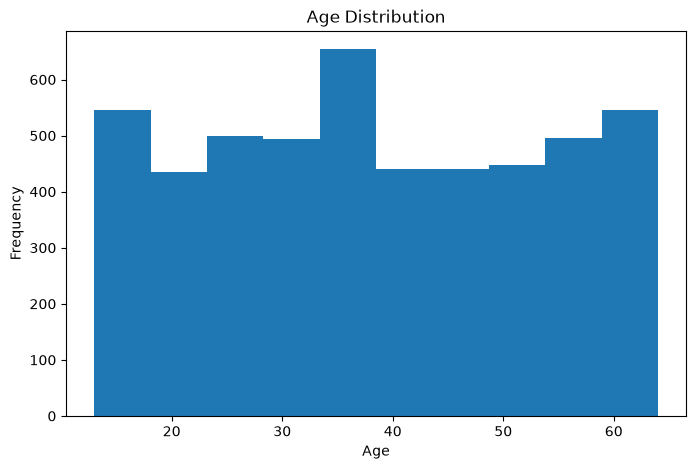

In [121]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"],bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### 6. Box Plot — Engagement Rate

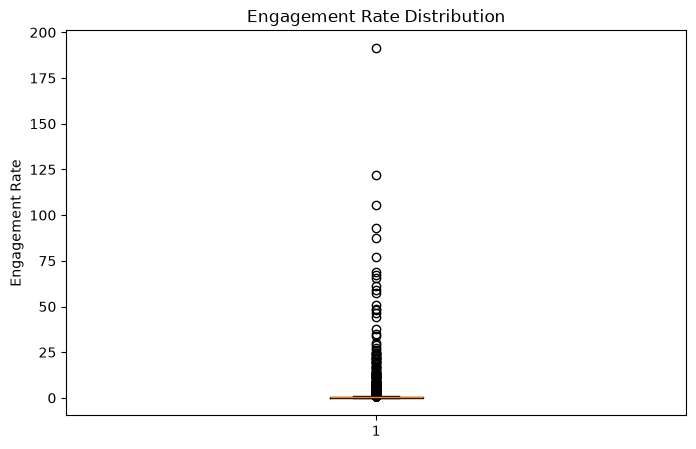

In [122]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["engagement_rate"].dropna())

plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate")
plt.show()

### Seaborn

#### 1. Count Plot — Post Type


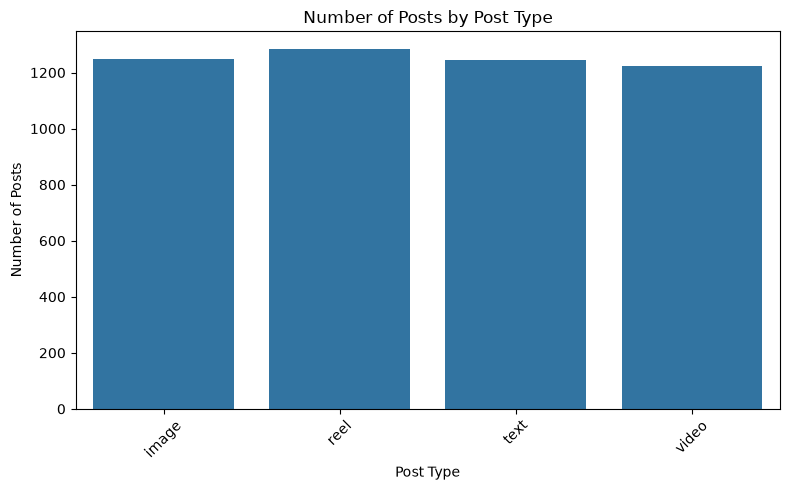

In [123]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="post_type")

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Bar Plot — Average Likes by Category

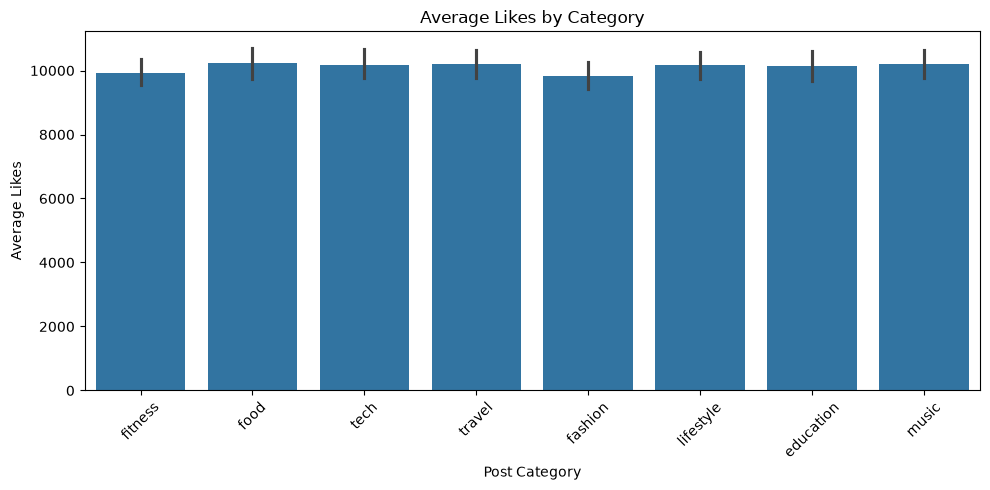

In [124]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df,x="post_category",y="likes",estimator="mean")

plt.title("Average Likes by Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3. Violin Plot — Followers vs Sentiment

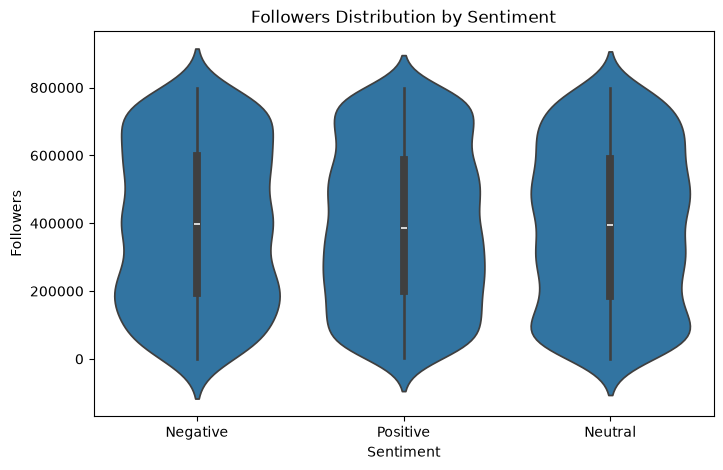

In [125]:

plt.figure(figsize=(8, 5))
sns.violinplot(data=df,x="sentiment",y="follower_count")

plt.title("Followers Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Followers")
plt.show()

#### 4. Pair Plot — Numeric Features

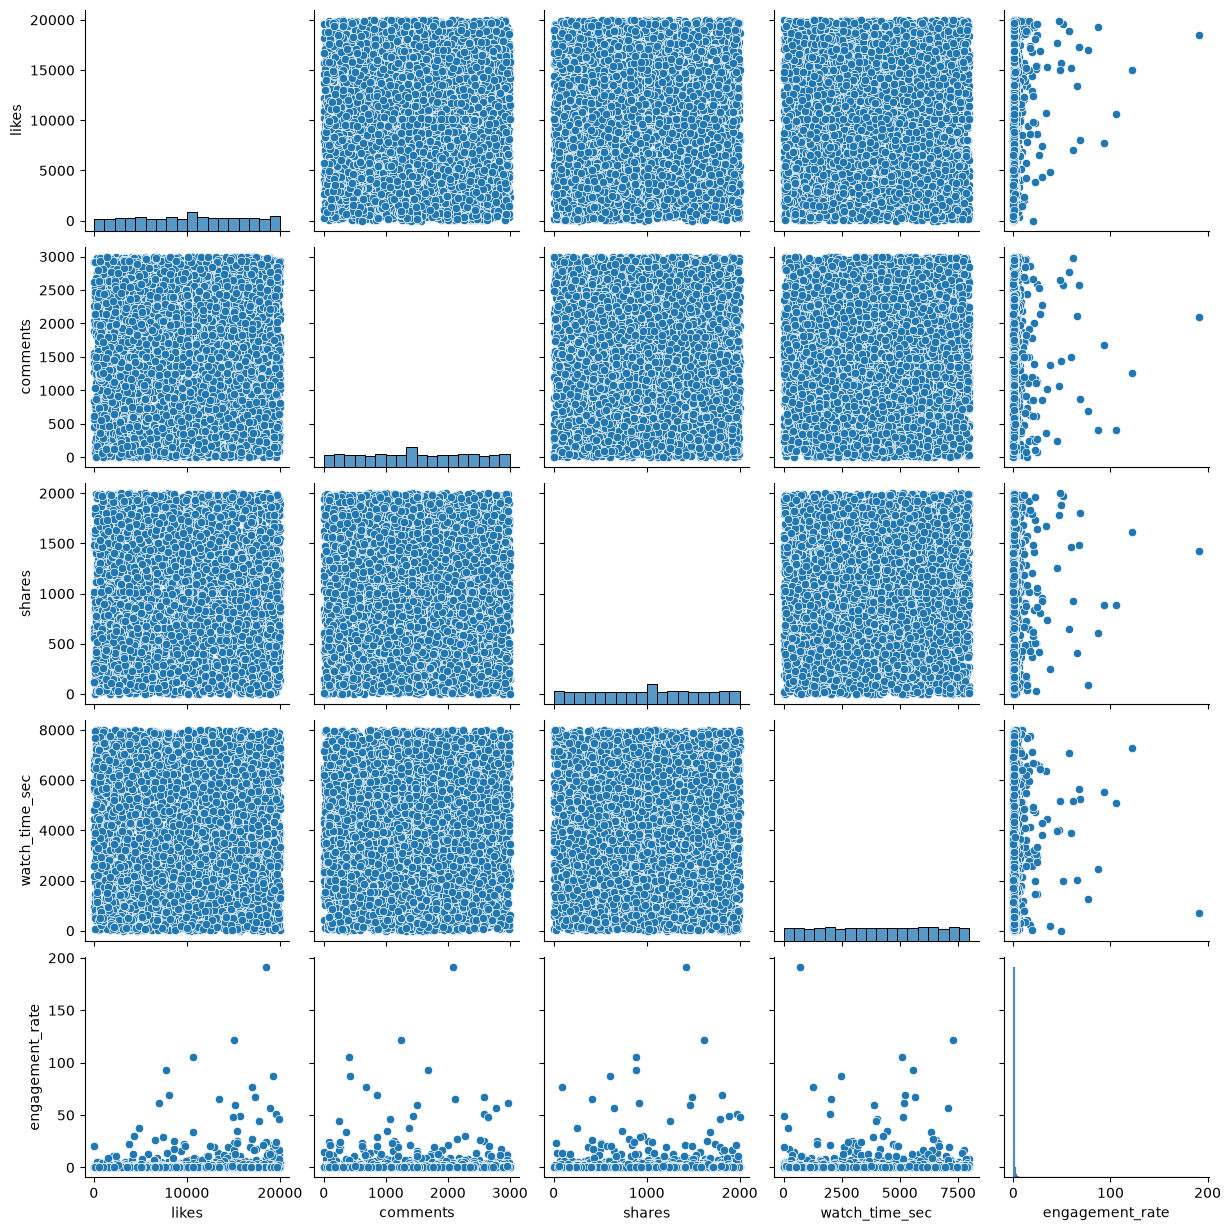

In [126]:
pair_columns = ["likes","comments","shares","watch_time_sec","engagement_rate"]

sns.pairplot(df[pair_columns].dropna())
plt.show()

#### 5. Heatmap — Correlation Matrix

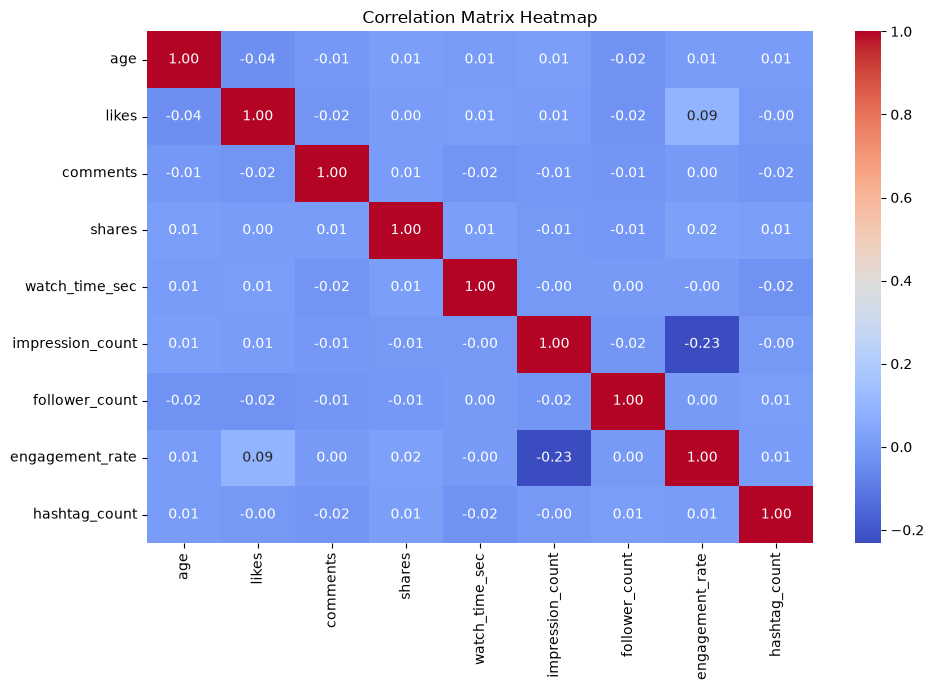

In [127]:
correlation_columns = ["age","likes","comments","shares","watch_time_sec","impression_count","follower_count","engagement_rate","hashtag_count"]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

#### 6. Swarm Plot — Engagement vs Device

c:\Users\dinuk\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 93.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dinuk\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 93.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dinuk\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 93.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dinuk\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 94.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

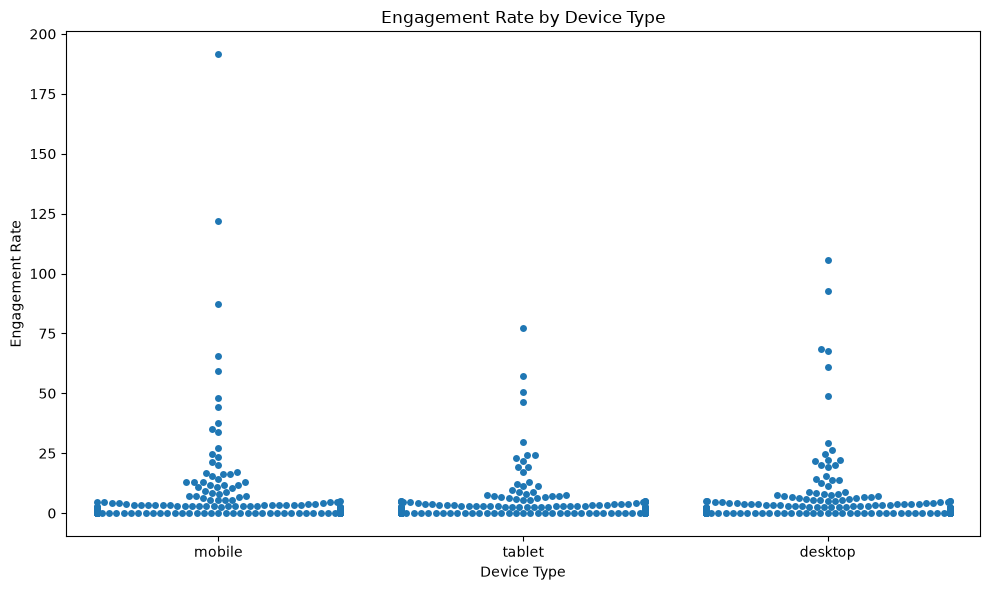

In [128]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=df,x="device_type",y="engagement_rate")

plt.title("Engagement Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

### Plotly (Interactive)

#### 1. Interactive Line Chart

In [129]:
daily_engagement = (df.groupby("posted_at")["engagement_rate"]
    .mean()
    .reset_index()
    .sort_values("posted_at")
)

fig = px.line(daily_engagement,
    x="posted_at",
    y="engagement_rate",
    title="Interactive Daily Engagement Trend",
    labels={"posted_at": "Date","engagement_rate": "Average Engagement Rate"}
)
fig.show()

#### 2. Interactive Bar Chart

In [130]:
category_engagement = (df.groupby("post_category")["likes"]
    .mean()
    .reset_index()
)

fig = px.bar(category_engagement,
    x="post_category",
    y="likes",
    title="Interactive Average Likes by Category",
    labels={"post_category": "Post Category","likes": "Average Likes"}
)

fig.show()

#### 3. Interactive Bubble Chart

In [131]:

bubble_data = (df.groupby("post_category")
    .agg(
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement_rate", "mean")
    )
    .reset_index()
)

fig = px.scatter(
    bubble_data,
    x="avg_likes",
    y="avg_comments",
    size="avg_engagement",
    color="post_category",
    hover_name="post_category",
    title="Interactive Bubble Chart — Category Engagement",
    labels={"avg_likes": "Average Likes","avg_comments": "Average Comments","avg_engagement": "Average Engagement Rate"}
)

fig.show()

#### 4. Interactive Scatter Chart

In [132]:
fig = px.scatter(
    df,
    x="likes",
    y="impression_count",
    color="post_type",
    hover_data=["post_category","country","engagement_rate"],
    title="Interactive Likes vs Impressions",
    labels={
        "likes": "Likes",
        "impression_count": "Impressions"}
)
fig.show()

### Final Insights

#### 1. Content Performance

In [133]:
# Which post types have highest engagement?
post_type_engagement = (
    df.groupby("post_type")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print("===== POST TYPE ENGAGEMENT =====")
display(post_type_engagement.to_frame(name="Average Engagement Rate")
)

===== POST TYPE ENGAGEMENT =====


,Average Engagement Rate
post_type,
video,1.122365
text,1.064549
image,0.895646
reel,0.783047


### Answer:
Video posts recorded the highest average engagement rate at approximately 1.1224, followed by Text (1.0645), Image (0.8956), and Reel (0.7830).

In [134]:
# Best-performing content category?
category_performance = (
    df.groupby("post_category")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print("\n===== CONTENT CATEGORY PERFORMANCE =====")
display(category_performance.to_frame(name="Average Engagement Rate")
)


===== CONTENT CATEGORY PERFORMANCE =====


,Average Engagement Rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


### Answer:
Food is the best-performing content category based on average engagement rate. It is followed by Tech and Lifestyle.

In [135]:
# Which countries have highest average engagement rate?
country_engagement = (
    df.groupby("country")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print("\n===== COUNTRY ENGAGEMENT =====")
display(
    country_engagement.head(5).to_frame(
        name="Average Engagement Rate")
)


===== COUNTRY ENGAGEMENT =====


,Average Engagement Rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659


### Answer:
Brazil has the highest average engagement rate among the countries in the dataset. The table above shows the top five countries ranked by average engagement rate.

#### User Trends

In [136]:
# How age affects engagement

age_engagement = (df.groupby("age")["engagement_rate"]
      .mean()
      .sort_index()
)

print("===== AVERAGE ENGAGEMENT RATE BY AGE =====")
display(age_engagement.to_frame(name="Average Engagement Rate")
)

# Correlation between age and engagement rate

age_correlation = df["age"].corr(df["engagement_rate"]
)

print("\nCorrelation between Age and Engagement Rate:")
print(round(age_correlation, 4))

===== AVERAGE ENGAGEMENT RATE BY AGE =====


,Average Engagement Rate
age,
13.0,0.455583
14.0,1.003067
15.0,0.714170
16.0,1.226848
17.0,0.858763
18.0,0.888391
19.0,0.676687
20.0,0.515541
21.0,0.452752



Correlation between Age and Engagement Rate:
0.008


### Answer:

The correlation between age and engagement rate is approximately 0.008.
This indicates a very weak linear relationship between age and engagement rate
in this dataset.

The average engagement rate by age is also shown in the table above.
Therefore, age does not show a strong linear relationship with engagement rate
in the analyzed dataset.

In [137]:
# Performance difference for verified accounts

verified_performance = (df.groupby("is_verified")["engagement_rate"]
      .mean()
)

print("\n===== AVERAGE ENGAGEMENT RATE BY VERIFIED STATUS =====")
display(verified_performance.to_frame(name="Average Engagement Rate")
)


===== AVERAGE ENGAGEMENT RATE BY VERIFIED STATUS =====


,Average Engagement Rate
is_verified,
False,0.954744
True,1.054250


### Answer:

Verified accounts recorded an average engagement rate of approximately 1.0542,
while non-verified accounts recorded an average engagement rate of approximately
0.9547.

Therefore, verified accounts had a higher average engagement rate than
non-verified accounts in this dataset.

### Behavioral Insights

In [138]:
# Best time of day for impressions

df["day_of_week"] = df["posted_at"].dt.day_name()
weekday_impressions = (
    df.groupby("day_of_week")["impression_count"]
      .mean()
      .sort_values(ascending=False)
)

print("===== AVERAGE IMPRESSIONS BY DAY OF WEEK =====")
display(weekday_impressions.to_frame(name="Average Impressions")
)

# Limitation for time-of-day analysis

print("\n===== TIME-OF-DAY LIMITATION =====")
print("The posted_at column contains dates only and has no hour/minute information.")
print("Therefore, the best time of day for impressions cannot be determined from this dataset.")

===== AVERAGE IMPRESSIONS BY DAY OF WEEK =====


,Average Impressions
day_of_week,
Tuesday,51308.589849
Saturday,50945.228095
Sunday,50345.670782
Monday,50013.224928
Wednesday,49857.990000
Friday,49430.537827
Thursday,48119.289398



===== TIME-OF-DAY LIMITATION =====
The posted_at column contains dates only and has no hour/minute information.
Therefore, the best time of day for impressions cannot be determined from this dataset.


### Answer:

The dataset contains the posting date but does not contain hour or minute information
in the `posted_at` column. Therefore, the exact best time of day for impressions
cannot be determined from this dataset.

However, the average impressions by day of the week were calculated above.
Tuesday recorded the highest average impressions among the days of the week.

In [139]:
# Device type impact on watch time

device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
      .mean()
      .sort_values(ascending=False)
)

print("\n===== AVERAGE WATCH TIME BY DEVICE TYPE =====")
display(device_watch_time.to_frame(name="Average Watch Time (Seconds)")
)


===== AVERAGE WATCH TIME BY DEVICE TYPE =====


,Average Watch Time (Seconds)
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


### Answer:

The average watch time differs across device types. Mobile devices recorded
the highest average watch time, followed by Tablet and Desktop devices.

In the dataset, the average watch time was approximately:

- Mobile: 4087.83 seconds
- Tablet: 3979.74 seconds
- Desktop: 3974.79 seconds

Therefore, Mobile had the highest average watch time among the device types.

### Sentiment Analysis

In [140]:
# 1. Which sentiment performs best?

sentiment_performance = (
    df.groupby("sentiment")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print("===== AVERAGE ENGAGEMENT RATE BY SENTIMENT =====")
display(sentiment_performance.to_frame(name="Average Engagement Rate")
)

===== AVERAGE ENGAGEMENT RATE BY SENTIMENT =====


,Average Engagement Rate
sentiment,
Negative,1.038486
Neutral,0.991170
Positive,0.919744


### Answer:

Negative sentiment posts recorded the highest average engagement rate at
approximately 1.0385, followed by Neutral sentiment posts at approximately
0.9912 and Positive sentiment posts at approximately 0.9197.

Therefore, Negative sentiment posts had the highest average engagement rate
in this dataset.

In [141]:
# 2. Behavior of Negative and Neutral Sentiment Posts

negative_neutral = (
    df[df["sentiment"].isin(["Negative", "Neutral"])]
    .groupby("sentiment")
    .agg(
        average_likes=("likes", "mean"),
        average_comments=("comments", "mean"),
        average_shares=("shares", "mean"),
        average_impressions=("impression_count", "mean"),
        average_watch_time=("watch_time_sec", "mean"),
        average_engagement_rate=("engagement_rate", "mean")
    )
    .sort_values("average_engagement_rate",ascending=False)
)

print("\n===== NEGATIVE AND NEUTRAL SENTIMENT POST BEHAVIOR =====")
display(negative_neutral)


===== NEGATIVE AND NEUTRAL SENTIMENT POST BEHAVIOR =====


,average_likes,average_comments,average_shares,average_impressions,average_watch_time,average_engagement_rate
sentiment,,,,,,
Negative,10208.096875,1516.094792,1007.307292,50191.960417,4054.639583,1.038486
Neutral,9923.194499,1528.404060,996.565160,49515.971185,4031.823183,0.991170


### Answer:

Negative sentiment posts had higher average likes, shares, impressions,
watch time, and engagement rate than Neutral sentiment posts.

Negative sentiment posts had an average engagement rate of approximately
1.0385, while Neutral posts had approximately 0.9912.

Neutral sentiment posts had slightly higher average comments than Negative
sentiment posts.

Overall, Negative sentiment posts showed higher engagement-related metrics
than Neutral posts in this dataset.

In [142]:
print("===== FINAL ASSIGNMENT CHECK =====")

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

print("\nFinal Data Types:")
print(df.dtypes)


===== FINAL ASSIGNMENT CHECK =====
Dataset shape: (5000, 25)
Number of columns: 25

Missing values:
0

Duplicate rows:
0

Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score', 'log_likes', 'log_comments', 'log_shares', 'day_of_week']

Final Data Types:
user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verifie

# **Project Title:** Social Media Engagement Analytics Using Python
   
#### **Name:** Dinukrishna A

### Project Overview

This project analyzes a social media engagement dataset containing 5,000 records using Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly. The analysis covers data cleaning, data exploration, data wrangling, statistical analysis, visualization, and final insights to identify patterns in social media engagement.

### Data Cleaning and Preparation

Missing values were identified using `isnull()` and `isna()`. Numerical missing values were handled using appropriate statistical methods such as median values, while categorical missing values were handled using mode values. Duplicate records were checked and removed. Data types and category labels were standardized, and invalid values in engagement-related fields were addressed.

### Data Wrangling and Statistical Analysis

The analysis included creating useful features such as `engagement_score` and `hashtag_count`, along with optional log-transformed metrics. Groupby analysis was performed based on post type, country, and sentiment. Statistical measures including standard deviation, variance, and percentiles were calculated for important numerical variables.

### Content Performance

Video posts recorded the highest average engagement rate at approximately **1.1224**, followed by Text (**1.0645**), Image (**0.8956**), and Reel (**0.7830**). Among content categories, **Food** had the highest average engagement rate at approximately **1.3586**. Among the countries analyzed, **Brazil** recorded the highest average engagement rate at approximately **1.5407**.

### User Trends

The correlation between age and engagement rate was approximately **0.008**, indicating a very weak linear relationship between age and engagement rate in this dataset. Verified accounts recorded an average engagement rate of approximately **1.0543**, compared with approximately **0.9547** for non-verified accounts.

### Behavioral Insights

The `posted_at` column contains dates but does not include hour or minute information. Therefore, the exact best time of day for impressions cannot be determined from this dataset. However, analysis by day of the week showed that **Tuesday** recorded the highest average impressions.

Device analysis showed that **Mobile** had the highest average watch time at approximately **4087.83 seconds**, followed by Tablet (**3979.74 seconds**) and Desktop (**3974.79 seconds**).

### Sentiment Analysis

**Negative** sentiment posts recorded the highest average engagement rate at approximately **1.0385**, followed by Neutral (**0.9912**) and Positive (**0.9197**).

Compared with Neutral sentiment posts, Negative sentiment posts had higher average likes, shares, impressions, watch time, and engagement rate. Neutral posts had slightly higher average comments.

### Conclusion

Overall, the analysis demonstrates how data cleaning, statistical analysis, grouping, correlation analysis, and visualization can be used to understand social media engagement patterns. The findings are descriptive and are based on the variables and records available in the provided dataset.